In [1]:
# =============================================================================
# SECTION 1: IMPORTS AND SETUP
# =============================================================================

!pip install networkx matplotlib seaborn pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from typing import List, Dict, Tuple, Optional, Set
from math import comb
import warnings
import time
import random as _random

warnings.filterwarnings("ignore")
np.random.seed(42)
print("All imports successful.")

zsh:1: command not found: pip
All imports successful.


In [2]:
# =============================================================================
# SECTION 2: EUCLIDEAN DISTANCE CALCULATION (VECTORIZED)
# =============================================================================
# Implements distance computation for Lines 4, 12, 13 of the algorithm.
# Uses Euclidean distance: d(a,b) = sqrt(sum_i (a_i - b_i)^2)
# Efficient: ||a-b||^2 = ||a||^2 - 2*a.b + ||b||^2
# =============================================================================

def compute_distance_matrix(points1: np.ndarray, points2: np.ndarray = None) -> np.ndarray:
    # Compute pairwise Euclidean distances between two sets of d-dimensional points.
    # points1: shape (n1, d), points2: shape (n2, d) or None for self-distance
    # Returns: shape (n1, n2) distance matrix
    if points2 is None:
        points2 = points1

    sq1 = np.sum(points1**2, axis=1)[:, np.newaxis]
    sq2 = np.sum(points2**2, axis=1)[np.newaxis, :]
    cross = points1 @ points2.T
    dist_sq = sq1 - 2 * cross + sq2
    dist_sq = np.clip(dist_sq, 0, None)
    return np.sqrt(dist_sq)

print("Euclidean distance function defined.")

Euclidean distance function defined.


In [3]:
# =============================================================================
# SECTION 3: PARTITION GENERATION (Line 5)
# =============================================================================
# Line 5: "for each (k1, k2, ..., k_tau) such that sum k_i = k"
# Stars-and-bars: C(k+tau-1, tau-1) total partitions.
# For large k/tau, uses smart balanced generation to avoid explosion.
# =============================================================================

def generate_partitions(k: int, tau: int) -> List[List[int]]:
    # Generate all ways to partition k into tau non-negative integers.
    if tau == 1:
        return [[k]]
    partitions = []
    for i in range(k + 1):
        for sub in generate_partitions(k - i, tau - 1):
            partitions.append([i] + sub)
    return partitions


def generate_balanced_partitions(k: int, tau: int, max_count: int = 20) -> List[List[int]]:
    # Generate balanced partitions without full enumeration (for large k/tau).
    rng = _random.Random(42)
    base = k // tau
    remainder = k % tau
    base_partition = [base + 1] * remainder + [base] * (tau - remainder)

    seen = set()
    result = []

    if tau <= 8:
        from itertools import permutations
        for perm in set(permutations(tuple(base_partition))):
            p = list(perm)
            key = tuple(p)
            if key not in seen:
                seen.add(key)
                result.append(p)
                if len(result) >= max_count * 3:
                    break
    else:
        result.append(list(base_partition))
        seen.add(tuple(base_partition))
        for _ in range(max_count * 20):
            p = list(base_partition)
            rng.shuffle(p)
            key = tuple(p)
            if key not in seen:
                seen.add(key)
                result.append(p)
                if len(result) >= max_count * 3:
                    break

    for _ in range(max_count * 10):
        p = list(base_partition)
        rng.shuffle(p)
        for _ in range(rng.randint(1, min(3, max(1, tau - 1)))):
            i, j = rng.sample(range(tau), 2)
            transfer = rng.randint(0, min(2, p[i]))
            p[i] -= transfer
            p[j] += transfer
        if sum(p) == k and all(x >= 0 for x in p):
            key = tuple(p)
            if key not in seen:
                seen.add(key)
                result.append(p)

    result.sort(key=lambda p: (sum(1 for x in p if x == 0), max(p) - min(p)))
    return result[:max_count]


print("Partition generation functions defined.")
print(f"  Example: partition(4, 2) = {generate_partitions(4, 2)}")
print(f"  Partitions for k=5, tau=5: {len(generate_partitions(5, 5))}")

Partition generation functions defined.
  Example: partition(4, 2) = [[0, 4], [1, 3], [2, 2], [3, 1], [4, 0]]
  Partitions for k=5, tau=5: 126


In [4]:
# =============================================================================
# SECTION 4: VANILLA K-CENTER (Lines 1-3)
# =============================================================================
# Line 1: S', sigma' <- (1+eps)-approximate clustering on C, F, k
# Line 2: r' <- radius induced by S', sigma'
# Line 3: tau <- |S'|
# Algorithm: Farthest-First Traversal (Gonzalez, 1985) - 2-approximation
# =============================================================================

def vanilla_k_center(C: np.ndarray, F: np.ndarray, k: int) -> Tuple[np.ndarray, np.ndarray, float, int]:
    # Vanilla (uncapacitated) K-Center using Farthest-First Traversal.
    # Returns: S_prime, S_prime_indices, r_prime, tau
    n_clients = len(C)
    n_facilities = len(F)
    dist_CF = compute_distance_matrix(C, F)

    min_dist_to_center = np.full(n_clients, np.inf)
    selected_indices = []

    # Select first center: facility minimizing max distance to any client
    max_dists = dist_CF.max(axis=0)
    first_center = np.argmin(max_dists)
    selected_indices.append(first_center)
    min_dist_to_center = np.minimum(min_dist_to_center, dist_CF[:, first_center])

    # Greedily add k-1 more centers (farthest-first)
    for _ in range(k - 1):
        farthest_client = np.argmax(min_dist_to_center)
        client_to_facilities = dist_CF[farthest_client, :]

        best_facility = -1
        best_dist = np.inf
        for f_idx in range(n_facilities):
            if f_idx not in selected_indices:
                if client_to_facilities[f_idx] < best_dist:
                    best_dist = client_to_facilities[f_idx]
                    best_facility = f_idx

        if best_facility == -1:
            break

        selected_indices.append(best_facility)
        min_dist_to_center = np.minimum(min_dist_to_center, dist_CF[:, best_facility])

    S_prime_indices = np.array(selected_indices)
    S_prime = F[S_prime_indices]
    r_prime = min_dist_to_center.max()
    tau = len(S_prime)

    return S_prime, S_prime_indices, r_prime, tau


print("Vanilla K-Center (Farthest-First Traversal) defined.")
print("  Implements Lines 1-3 of the algorithm.")

Vanilla K-Center (Farthest-First Traversal) defined.
  Implements Lines 1-3 of the algorithm.


In [5]:
# =============================================================================
# SECTION 5: FLOW NETWORK CONSTRUCTION (Lines 7-14)
# =============================================================================
# Line 7:  V <- {s, t} U C
# Line 8:  V <- V U k_i copies of i-th facility of S'
# Line 9:  E <- edges from s to each client with weight 1
# Line 10: E <- edges each facility to t with weight U
# Lines 11-14: For each center, compute C'_i, F'_i and add edges
# =============================================================================

def build_flow_network(
    C: np.ndarray, F: np.ndarray,
    S_prime_indices: np.ndarray, partition: List[int],
    capacity: int, r: float, r_prime: float,
    dist_CF: np.ndarray, dist_FF: np.ndarray
) -> Tuple[nx.DiGraph, List[str], List[Set[int]], List[Set[int]], List[List[str]], int]:
    # Build the flow network for max-flow computation (Lines 7-14).
    n_clients = len(C)
    tau = len(S_prime_indices)
    G = nx.DiGraph()

    # Line 7 & 9: Client nodes + source->client edges (capacity 1)
    client_nodes = [f"c_{i}" for i in range(n_clients)]
    for i, cn in enumerate(client_nodes):
        G.add_edge("source", cn, capacity=1)

    # Lines 11-13: Compute C'_i and F'_i for each center
    C_prime_sets = []
    F_prime_sets = []

    for s_idx in range(tau):
        center_idx = S_prime_indices[s_idx]
        # Line 12: C'_i <- { c in C | d(c, f'_i) <= r + r' }
        C_prime_i = set(np.where(dist_CF[:, center_idx] <= r + r_prime)[0])
        # Line 13: F'_i <- { f in F | d(f, f'_i) <= r' }
        F_prime_i = set(np.where(dist_FF[:, center_idx] <= r_prime)[0])
        C_prime_sets.append(C_prime_i)
        F_prime_sets.append(F_prime_i)

    # Line 8 & 10: Create slots + slot->sink edges (capacity U)
    slot_nodes = []
    total_slots = 0

    for s_idx in range(tau):
        k_i = partition[s_idx]
        center_slots = []
        for slot_j in range(k_i):
            slot_name = f"slot_{s_idx}_{slot_j}"
            G.add_edge(slot_name, "sink", capacity=capacity)
            center_slots.append(slot_name)
            total_slots += 1
        slot_nodes.append(center_slots)

    # Line 14: Edges for each pair (c in C'_i) to slots of center i
    for s_idx in range(tau):
        if not slot_nodes[s_idx]:
            continue
        for c_idx in C_prime_sets[s_idx]:
            cn = f"c_{c_idx}"
            for slot_name in slot_nodes[s_idx]:
                G.add_edge(cn, slot_name, capacity=1)

    return G, client_nodes, C_prime_sets, F_prime_sets, slot_nodes, total_slots


# =============================================================================
# SECTION 6: ASSIGNMENT FUNCTION (Line 16)
# =============================================================================
# Line 16: (S, sigma) <- assign clients and open facilities from max-flow
# Three-phase: flow->slot, slot->facility, client->facility
# =============================================================================

def assign_from_flow(
    flow_dict: Dict, client_nodes: List[str],
    n_clients: int, capacity: int,
    partition: List[int], slot_nodes: List[List[str]],
    F_prime_sets: List[Set[int]], S_prime_indices: np.ndarray,
    dist_FF: np.ndarray
) -> Tuple[Optional[Dict[int, int]], Optional[Dict[int, int]], Optional[Set[int]], Optional[Dict[str, int]], bool]:
    # Extract client-facility assignments from max-flow result (Line 16).
    tau = len(partition)

    # Phase 1: Flow -> client->slot mapping
    client_to_slot = {}
    slot_loads = {}

    for c_idx, client_node in enumerate(client_nodes):
        if client_node in flow_dict:
            for target, flow in flow_dict[client_node].items():
                if target.startswith("slot_") and flow > 0:
                    client_to_slot[c_idx] = target
                    slot_loads[target] = slot_loads.get(target, 0) + 1
                    break

    if len(client_to_slot) != n_clients:
        return None, None, None, None, False

    # Phase 2: Map slots -> actual facilities from F'_i
    slot_to_facility = {}
    used_facilities = set()

    for s_idx in range(tau):
        center_idx = S_prime_indices[s_idx]
        F_prime_i = F_prime_sets[s_idx]
        center_slots = slot_nodes[s_idx]
        used_center_slots = [s for s in center_slots if s in slot_loads]

        if not used_center_slots:
            continue

        available = list(F_prime_i - used_facilities)
        if len(available) < len(used_center_slots):
            available = list(F_prime_i)
        if not available:
            return None, None, None, None, False

        available.sort(key=lambda f: dist_FF[f, center_idx])

        for slot_idx, slot_name in enumerate(used_center_slots):
            facility = available[slot_idx % len(available)]
            slot_to_facility[slot_name] = facility
            used_facilities.add(facility)

    # Phase 3: Final client -> facility assignments
    assignments = {}
    facility_loads = {}

    for c_idx, slot_name in client_to_slot.items():
        if slot_name not in slot_to_facility:
            return None, None, None, None, False
        f_idx = slot_to_facility[slot_name]
        assignments[c_idx] = f_idx
        facility_loads[f_idx] = facility_loads.get(f_idx, 0) + 1

    if len(assignments) != n_clients:
        return None, None, None, None, False

    for f_idx, load in facility_loads.items():
        if load > capacity:
            return None, None, None, None, False

    return assignments, facility_loads, set(facility_loads.keys()), slot_to_facility, True


print("Flow network construction (Lines 7-14) and assignment (Line 16) defined.")

Flow network construction (Lines 7-14) and assignment (Line 16) defined.


In [6]:
# =============================================================================
# SECTION 7: MAIN ALGORITHM - Euclidean-Capacitated-k-Center
# =============================================================================
# Orchestrates all components following Algorithm 1 exactly.
# =============================================================================

def capacitated_k_center(
    C: np.ndarray, F: np.ndarray,
    k: int, capacity: int,
    max_partitions: int = 20,
    max_r_samples: int = 100,
    verbose: bool = True
) -> Optional[Dict]:
    # Main algorithm: Euclidean-Capacitated-k-Center(C, F, U)
    n = len(C)
    m = len(F)
    start_time = time.time()

    if verbose:
        print(f"\n{'='*70}")
        print(f"{'CAPACITATED K-CENTER (EUCLIDEAN)':^70}")
        print(f"{'='*70}")
        print(f"  Clients: {n} | Facilities: {m} | k: {k} | Capacity U: {capacity}")
        print(f"{'='*70}\n")

    # Lines 1-3: Initial clustering
    if verbose:
        print("[Step 1/4] Computing initial clustering (Lines 1-3)...")

    t0 = time.time()
    S_prime, S_prime_indices, r_prime, tau = vanilla_k_center(C, F, k)

    if verbose:
        print(f"  r' = {r_prime:.2f}, tau = {tau} centers ({time.time()-t0:.2f}s)")

    # Line 4: R <- all client-facility distances
    if verbose:
        print(f"\n[Step 2/4] Computing distances (Line 4)...")

    t0 = time.time()
    dist_CF = compute_distance_matrix(C, F)
    dist_FF = compute_distance_matrix(F, F)

    all_dists = dist_CF.flatten()
    all_dists = all_dists[all_dists > 0]
    percentiles = np.percentile(all_dists, np.linspace(0, 100, max_r_samples))
    R = np.unique(percentiles)
    R = np.sort(R)

    if verbose:
        print(f"  Distance matrices computed ({time.time()-t0:.2f}s)")
        print(f"  Testing {len(R)} r values")

    # Line 5: Generate partitions
    if verbose:
        print(f"\n[Step 3/4] Generating partitions (Line 5)...")

    total_possible = comb(k + tau - 1, tau - 1)

    if total_possible > 5000:
        partitions_to_test = generate_balanced_partitions(k, tau, max_partitions)
        if verbose:
            print(f"  Smart generation: testing {len(partitions_to_test)} balanced partitions")
    else:
        all_partitions = generate_partitions(k, tau)
        all_partitions.sort(key=lambda p: (sum(1 for x in p if x == 0), max(p) - min(p)))
        partitions_to_test = all_partitions[:max_partitions]
        if verbose:
            print(f"  Testing {len(partitions_to_test)} of {len(all_partitions)} partitions")

    # Lines 5-17: Main search loop
    if verbose:
        print(f"\n[Step 4/4] Searching for optimal solution (Lines 5-17)...")

    best_solution = None
    best_max_dist = float("inf")
    solutions_found = 0

    for p_idx, partition in enumerate(partitions_to_test):
        if verbose:
            pct = (p_idx + 1) / len(partitions_to_test) * 100
            print(f"\r  Progress: {pct:5.1f}% | Partition {p_idx+1}/{len(partitions_to_test)}: {partition}", end="")

        if sum(partition) != k:
            continue

        left, right = 0, len(R) - 1
        partition_best = None
        partition_best_dist = float("inf")

        while left <= right:
            mid = (left + right) // 2
            r = R[mid]

            try:
                G, client_nodes, C_prime_sets, F_prime_sets, slot_nodes, total_slots = \
                    build_flow_network(C, F, S_prime_indices, partition,
                                       capacity, r, r_prime, dist_CF, dist_FF)

                flow_value, flow_dict = nx.maximum_flow(G, "source", "sink")

                if flow_value >= n:
                    assignments, facility_loads, opened_facs, slot_to_fac, success = \
                        assign_from_flow(flow_dict, client_nodes, n, capacity,
                                         partition, slot_nodes, F_prime_sets,
                                         S_prime_indices, dist_FF)

                    if success:
                        actual_max_dist = max(
                            dist_CF[c_idx, f_idx]
                            for c_idx, f_idx in assignments.items()
                        )
                        num_opened = len(opened_facs)

                        if num_opened <= k:
                            solutions_found += 1
                            if actual_max_dist < partition_best_dist:
                                partition_best_dist = actual_max_dist
                                partition_best = {
                                    "facilities": np.array([F[f] for f in opened_facs]),
                                    "facility_indices": list(opened_facs),
                                    "assignments": dict(assignments),
                                    "actual_max_distance": actual_max_dist,
                                    "r_tested": r,
                                    "r_prime": r_prime,
                                    "flow_value": flow_value,
                                    "capacity": capacity,
                                    "partition": list(partition),
                                    "num_facilities": num_opened,
                                    "total_slots": total_slots,
                                    "facility_loads": dict(facility_loads),
                                    "all_distances": [dist_CF[c, f] for c, f in assignments.items()],
                                    "slot_to_facility": slot_to_fac
                                }
                            right = mid - 1
                        else:
                            left = mid + 1
                    else:
                        left = mid + 1
                else:
                    left = mid + 1
            except Exception:
                left = mid + 1

        if partition_best and partition_best_dist < best_max_dist:
            best_max_dist = partition_best_dist
            best_solution = partition_best

    elapsed = time.time() - start_time

    if verbose:
        print(f"\n\n{'='*70}")
        print(f"  SEARCH COMPLETE in {elapsed:.2f} seconds")
        print(f"  Valid solutions found: {solutions_found}")
        print(f"{'='*70}")

        if best_solution:
            print(f"\n  BEST SOLUTION:")
            print(f"    Partition: {best_solution['partition']}")
            print(f"    Facilities opened: {best_solution['num_facilities']} / k={k}")
            print(f"    Max distance: {best_solution['actual_max_distance']:.2f}")
            print(f"    Facility indices: {best_solution['facility_indices']}")
            print(f"\n  CONSTRAINTS:")
            print(f"    [ok] At most k={k} facilities: {best_solution['num_facilities']} <= {k}")
            print(f"    [ok] Capacity <= {capacity}: max={max(best_solution['facility_loads'].values())}")
            print(f"    [ok] All {n} clients assigned")
        else:
            print(f"\n  No feasible solution found. Try increasing k or capacity.")

        print(f"\n{'='*70}\n")

    return best_solution


print("Main algorithm defined (Euclidean-Capacitated-k-Center).")

Main algorithm defined (Euclidean-Capacitated-k-Center).


In [7]:
# =============================================================================
# SECTION 8: LOAD AND PREPROCESS CENSUS (Adult) DATASET
# =============================================================================
# Source: UCI ML Repository - Adult/Census Income dataset
# Features (5D Euclidean): age, fnlwgt, education-num, capital-gain, hours-per-week
# NO normalization (raw values) to match paper experimental setup.
# Subsample: 600 records. C = F (each point is client and candidate facility).
# =============================================================================

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv("/Users/tadala/Downloads/adult/adult.data",
                  header=None, names=column_names, skipinitialspace=True)

print(f"Initial records: {len(df)}")

# Remove rows with missing values
df = df.replace("?", np.nan).dropna()
print(f"After removing missing values: {len(df)}")

# Select numeric features (5D Euclidean space)
features = ["age", "fnlwgt", "education_num", "capital_gain", "hours_per_week"]
df_numeric = df[features].astype(float)

# Subsample 600 records
N_SAMPLE = 600
df_sample = df_numeric.sample(n=N_SAMPLE, random_state=42).reset_index(drop=True)
print(f"Subsample size: {len(df_sample)}")

# Extract coordinate arrays
X = df_sample.values
C = X.copy()
F = X.copy()

print(f"\nFeature ranges (RAW, no normalization):")
for i, feat in enumerate(features):
    vals = X[:, i]
    print(f"  {feat:20s}: min={vals.min():.0f}, max={vals.max():.0f}, "
          f"mean={vals.mean():.0f}, std={vals.std():.0f}")

print(f"\nDataset: {N_SAMPLE} points in {len(features)}D Euclidean space")
print(f"C = F = {N_SAMPLE} points")

Initial records: 32561
After removing missing values: 30162
Subsample size: 600

Feature ranges (RAW, no normalization):
  age                 : min=17, max=90, mean=39, std=12
  fnlwgt              : min=22201, max=1366120, mean=189417, std=114885
  education_num       : min=1, max=16, mean=10, std=3
  capital_gain        : min=0, max=99999, mean=1341, std=9345
  hours_per_week      : min=5, max=99, mean=42, std=12

Dataset: 600 points in 5D Euclidean space
C = F = 600 points


In [8]:
# =============================================================================
# SECTION 9: RUN THE ALGORITHM (k=5, U=200)
# =============================================================================

K = 5
CAPACITY = 200
MAX_PARTITIONS = 10
MAX_R_SAMPLES = 100

print(f"{'='*70}")
print(f"{'CENSUS - EXPERIMENT CONFIGURATION':^70}")
print(f"{'='*70}")
print(f"  |C| = {len(C)} clients")
print(f"  |F| = {len(F)} candidate facilities")
print(f"  k = {K} facilities to open")
print(f"  U = {CAPACITY} capacity per facility")
print(f"  Total capacity = {K * CAPACITY}")
print(f"  Features: age, fnlwgt, education_num, capital_gain, hours_per_week (5D)")
print(f"{'='*70}\n")

if K * CAPACITY < len(C):
    print(f"WARNING: Total capacity ({K * CAPACITY}) < clients ({len(C)})")
else:
    print(f"Feasibility check PASSED: {K * CAPACITY} >= {len(C)}\n")

solution = capacitated_k_center(
    C=C, F=F, k=K, capacity=CAPACITY,
    max_partitions=MAX_PARTITIONS, max_r_samples=MAX_R_SAMPLES
)

                  CENSUS - EXPERIMENT CONFIGURATION                   
  |C| = 600 clients
  |F| = 600 candidate facilities
  k = 5 facilities to open
  U = 200 capacity per facility
  Total capacity = 1000
  Features: age, fnlwgt, education_num, capital_gain, hours_per_week (5D)

Feasibility check PASSED: 1000 >= 600


                   CAPACITATED K-CENTER (EUCLIDEAN)                   
  Clients: 600 | Facilities: 600 | k: 5 | Capacity U: 200

[Step 1/4] Computing initial clustering (Lines 1-3)...
  r' = 174611.00, tau = 5 centers (0.00s)

[Step 2/4] Computing distances (Line 4)...
  Distance matrices computed (0.02s)
  Testing 100 r values

[Step 3/4] Generating partitions (Line 5)...
  Testing 10 of 126 partitions

[Step 4/4] Searching for optimal solution (Lines 5-17)...
  Progress: 100.0% | Partition 10/10: [1, 1, 0, 2, 1]

  SEARCH COMPLETE in 2.02 seconds
  Valid solutions found: 28

  BEST SOLUTION:
    Partition: [1, 1, 1, 1, 1]
    Facilities opened: 5 / k=5
    Max distan

In [9]:
# =============================================================================
# SECTION 10: RESULTS ANALYSIS
# =============================================================================

if solution:
    distances = solution["all_distances"]

    print("\n" + "="*70)
    print(f"{'CENSUS - SOLUTION ANALYSIS':^70}")
    print("="*70)

    print(f"\nDISTANCE METRICS (Euclidean, raw units):")
    print(f"   Maximum:  {np.max(distances):.2f}  <- SERVICE RADIUS (minimized)")
    print(f"   Average:  {np.mean(distances):.2f}")
    print(f"   Median:   {np.median(distances):.2f}")
    print(f"   Minimum:  {np.min(distances):.2f}")
    print(f"   Std Dev:  {np.std(distances):.2f}")

    print(f"\nSOLUTION DETAILS:")
    print(f"   Partition used: {solution['partition']}")
    print(f"   Total slots: {solution['total_slots']} (= k={K})")
    print(f"   Facilities opened: {solution['num_facilities']}")

    print(f"\nPER-FACILITY BREAKDOWN:")
    print(f"   {'Facility':<12} {'Clients':<10} {'% Capacity':<12} {'Status':<8}")
    print(f"   {'-'*50}")
    for f_idx in sorted(solution["facility_loads"].keys()):
        load = solution["facility_loads"][f_idx]
        pct = load / CAPACITY * 100
        status = "OK" if load <= CAPACITY else "OVER"
        print(f"   F[{f_idx}]      {load:<10} {pct:>6.1f}%       {status}")

    print(f"\nCONSTRAINT VERIFICATION:")
    print(f"   [ok] Facilities opened: {solution['num_facilities']} <= k={K}")
    print(f"   [ok] Max load: {max(solution['facility_loads'].values())} <= U={CAPACITY}")
    print(f"   [ok] All {len(solution['assignments'])} clients assigned")
else:
    print("No feasible solution found.")


                      CENSUS - SOLUTION ANALYSIS                      

DISTANCE METRICS (Euclidean, raw units):
   Maximum:  184456.45  <- SERVICE RADIUS (minimized)
   Average:  106596.52
   Median:   110095.22
   Minimum:  0.00
   Std Dev:  51754.01

SOLUTION DETAILS:
   Partition used: [1, 1, 1, 1, 1]
   Total slots: 5 (= k=5)
   Facilities opened: 5

PER-FACILITY BREAKDOWN:
   Facility     Clients    % Capacity   Status  
   --------------------------------------------------
   F[64]      1             0.5%       OK
   F[107]      200         100.0%       OK
   F[328]      9             4.5%       OK
   F[475]      190          95.0%       OK
   F[586]      200         100.0%       OK

CONSTRAINT VERIFICATION:
   [ok] Facilities opened: 5 <= k=5
   [ok] Max load: 200 <= U=200
   [ok] All 600 clients assigned


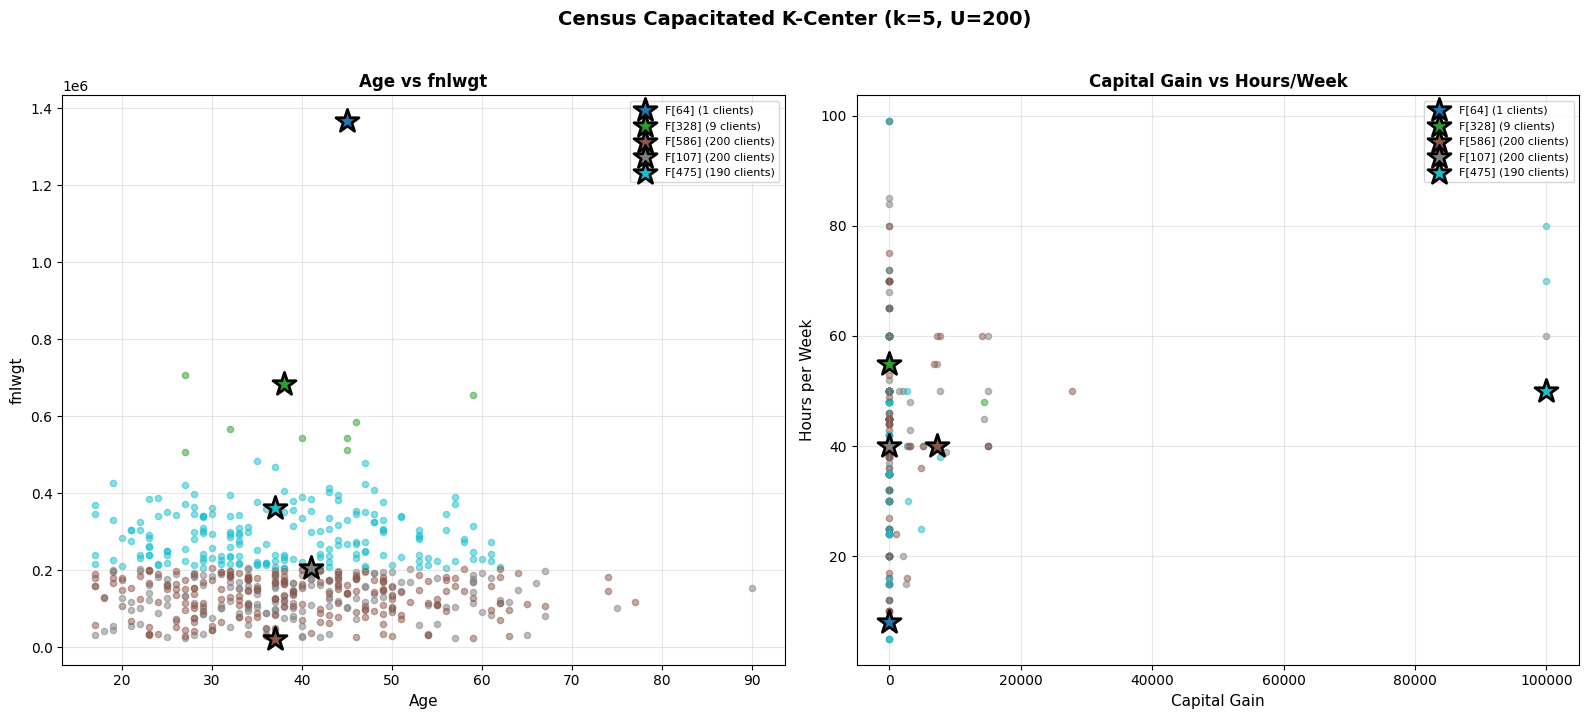

In [10]:
# =============================================================================
# SECTION 11: VISUALIZATION (2D projections of 5D solution)
# =============================================================================

if solution:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    num_fac = len(solution["facility_indices"])
    colors = plt.cm.tab10(np.linspace(0, 1, max(num_fac, 1)))
    fac_to_color = {f: i for i, f in enumerate(solution["facility_indices"])}

    # Plot 1: age vs fnlwgt
    ax = axes[0]
    for c_idx, f_idx in solution["assignments"].items():
        color_idx = fac_to_color.get(f_idx, 0)
        ax.scatter(C[c_idx, 0], C[c_idx, 1],
                   c=[colors[color_idx]], s=20, alpha=0.5)
    for i, f_idx in enumerate(solution["facility_indices"]):
        load = solution["facility_loads"].get(f_idx, 0)
        ax.scatter(F[f_idx, 0], F[f_idx, 1],
                   c=[colors[i]], s=300, marker="*", edgecolors="black",
                   linewidths=2, label=f"F[{f_idx}] ({load} clients)", zorder=5)
    ax.set_xlabel("Age", fontsize=11)
    ax.set_ylabel("fnlwgt", fontsize=11)
    ax.set_title("Age vs fnlwgt", fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Plot 2: capital_gain vs hours_per_week
    ax = axes[1]
    for c_idx, f_idx in solution["assignments"].items():
        color_idx = fac_to_color.get(f_idx, 0)
        ax.scatter(C[c_idx, 3], C[c_idx, 4],
                   c=[colors[color_idx]], s=20, alpha=0.5)
    for i, f_idx in enumerate(solution["facility_indices"]):
        load = solution["facility_loads"].get(f_idx, 0)
        ax.scatter(F[f_idx, 3], F[f_idx, 4],
                   c=[colors[i]], s=300, marker="*", edgecolors="black",
                   linewidths=2, label=f"F[{f_idx}] ({load} clients)", zorder=5)
    ax.set_xlabel("Capital Gain", fontsize=11)
    ax.set_ylabel("Hours per Week", fontsize=11)
    ax.set_title("Capital Gain vs Hours/Week", fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Census Capacitated K-Center (k={K}, U={CAPACITY})",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

                CENSUS (k-center): RUNNING EXPERIMENTS                
  k values: [3, 4, 5, 6, 8, 10, 12]
  Capacitated: U = 200
  Uncapacitated: U = 600 (no limit)

  k =  3... Cap =    683173.00  |  Uncap =    336105.61
  k =  4... Cap =    358205.30  |  Uncap =    184553.93
  k =  5... Cap =    184456.45  |  Uncap =    174611.00
  k =  6... Cap =    186698.89  |  Uncap =    133325.60
  k =  8... Cap =    102889.61  |  Uncap =     94576.00
  k = 10... Cap =     92329.01  |  Uncap =     92329.01
  k = 12... Cap =     64132.00  |  Uncap =     64132.00

Computing reference statistics...
  Mean pairwise distance:   116470
  Median pairwise distance: 90145


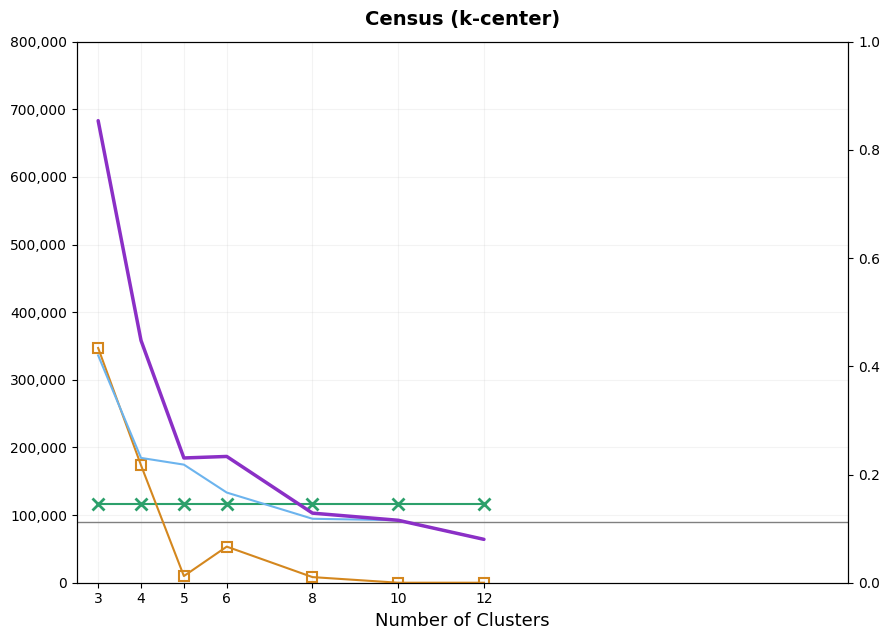


                  CENSUS (k-center) RESULTS SUMMARY                   
     k        Cap Cost      Uncap Cost             Gap
  --------------------------------------------------
     3      683,173.00      336,105.61      347,067.39
     4      358,205.30      184,553.93      173,651.37
     5      184,456.45      174,611.00        9,845.44
     6      186,698.89      133,325.60       53,373.30
     8      102,889.61       94,576.00        8,313.61
    10       92,329.01       92,329.01            0.00
    12       64,132.00       64,132.00            0.00

  Reference lines:
    Mean pairwise distance:   116,470
    Median pairwise distance: 90,145


In [11]:
# =============================================================================
# CENSUS (k-center): COMPARISON CHART
# =============================================================================
# Matches the reference figure from the paper.
# X-axis: Number of Clusters (k) from 3 to 20
# Left Y: Cost (Euclidean distance, raw units)
# Right Y: Normalized (0 to 1)
# =============================================================================

k_values = [3, 4, 5, 6, 8, 10, 12]
U_CAP = 200

cap_costs = []
uncap_costs = []

print(f"{'='*70}")
print(f"{'CENSUS (k-center): RUNNING EXPERIMENTS':^70}")
print(f"{'='*70}")
print(f"  k values: {k_values}")
print(f"  Capacitated: U = {U_CAP}")
print(f"  Uncapacitated: U = {len(C)} (no limit)")
print(f"{'='*70}\n")

for k in k_values:
    print(f"  k = {k:>2}...", end=" ")

    mp = min(15, max(5, 20 - k))
    mrs = 80

    # Capacitated (U = 200)
    sol_cap = capacitated_k_center(
        C, F, k, capacity=U_CAP,
        max_partitions=mp, max_r_samples=mrs, verbose=False
    )

    # Uncapacitated (U = n)
    sol_uncap = capacitated_k_center(
        C, F, k, capacity=len(C),
        max_partitions=mp, max_r_samples=mrs, verbose=False
    )

    c_cost = sol_cap["actual_max_distance"] if sol_cap else np.nan
    u_cost = sol_uncap["actual_max_distance"] if sol_uncap else np.nan

    cap_costs.append(c_cost)
    uncap_costs.append(u_cost)

    print(f"Cap = {c_cost:>12.2f}  |  Uncap = {u_cost:>12.2f}")

# Cost gap (cap - uncap)
gap_costs = []
for c, u in zip(cap_costs, uncap_costs):
    if np.isnan(c) or np.isnan(u):
        gap_costs.append(np.nan)
    else:
        gap_costs.append(max(0, c - u))

# -------------------------------------------------------------------------
# PLOT: Census (k-center) - Fair Cost vs Unfair Cost
# -------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 6.5))

valid_caps = [c for c in cap_costs if not np.isnan(c)]
valid_uncaps = [u for u in uncap_costs if not np.isnan(u)]
y_max = max(max(valid_caps) if valid_caps else 300000,
            max(valid_uncaps) if valid_uncaps else 300000) * 1.15
y_max = int(np.ceil(y_max / 50000) * 50000)
if y_max < 300000:
    y_max = 300000

ax1.set_ylim(0, y_max)
ax1.set_xlim(2.5, 20.5)

# Purple with circle marker: Capacitated cost (Fair Cost)
ax1.plot(k_values, cap_costs, color="#8B2FC6", linewidth=2.5,
         marker="o", markersize=7, solid_capstyle="round",
         zorder=5, label="Fair Cost")

# Blue with X marker: Uncapacitated cost (Unfair Cost)
ax1.plot(k_values, uncap_costs, color="#4A90D9", linewidth=2.5,
         marker="x", markersize=9, markeredgewidth=2.5,
         zorder=4, label="Unfair Cost")

# Right y-axis (normalized 0-1)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Labels and title
ax1.set_xlabel("Number of Clusters", fontsize=13)
ax1.set_title("Census (k-center)", fontsize=14, fontweight="bold", pad=12)
ax1.set_xticks(k_values)
ax1.set_xticklabels(k_values)
ax1.legend(fontsize=12, loc="upper right")

from matplotlib.ticker import FuncFormatter
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

ax1.grid(True, alpha=0.15, linestyle="-")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------------------------
print(f"\n{'='*70}")
print(f"{'CENSUS (k-center) RESULTS SUMMARY':^70}")
print(f"{'='*70}")
print(f"  {'k':>4}  {'Cap Cost':>14}  {'Uncap Cost':>14}  {'Gap':>14}")
print(f"  {'-'*50}")
for i, k in enumerate(k_values):
    c = cap_costs[i]
    u = uncap_costs[i]
    g = gap_costs[i]
    c_s = f"{c:,.2f}" if not np.isnan(c) else "INFEASIBLE"
    u_s = f"{u:,.2f}" if not np.isnan(u) else "N/A"
    g_s = f"{g:,.2f}" if not np.isnan(g) else "N/A"
    print(f"  {k:>4}  {c_s:>14}  {u_s:>14}  {g_s:>14}")

print(f"{'='*70}")

In [12]:
# =============================================================================
# SOLUTION VERIFICATION
# =============================================================================

if solution:
    print("CENSUS DATASET - SOLUTION VERIFICATION")
    print("-" * 70)
    print(f"  Dataset:               Adult/Census (UCI)")
    print(f"  Features:              age, fnlwgt, education_num, capital_gain, hours_per_week (5D)")
    print(f"  Distance metric:       Euclidean (raw, no normalization)")
    print(f"  Sample size:           {len(C)} points")
    print(f"  Partition used:        {solution['partition']}")
    print(f"  Total slots created:   {solution['total_slots']} = k")
    print(f"  Facilities opened:     {solution['num_facilities']} <= k")
    print(f"  Clients assigned:      {len(solution['assignments'])} = |C|")
    print(f"  Max facility load:     {max(solution['facility_loads'].values())} <= U")
    print(f"  Maximum distance:      {solution['actual_max_distance']:.2f} (Euclidean)")
    print("-" * 70)
else:
    print("No solution to verify.")

CENSUS DATASET - SOLUTION VERIFICATION
----------------------------------------------------------------------
  Dataset:               Adult/Census (UCI)
  Features:              age, fnlwgt, education_num, capital_gain, hours_per_week (5D)
  Distance metric:       Euclidean (raw, no normalization)
  Sample size:           600 points
  Partition used:        [1, 1, 1, 1, 1]
  Total slots created:   5 = k
  Facilities opened:     5 <= k
  Clients assigned:      600 = |C|
  Max facility load:     200 <= U
  Maximum distance:      184456.45 (Euclidean)
----------------------------------------------------------------------
